In [1]:
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pyphot
from pyphot import UnitFilter
import pandas as pd
import re

In [2]:
# Define root 
root_dir = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/AMBRE')
root_filt = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/filter')
# Define pattern for the name
pattern = re.compile(r'[a-zA-Z_]*[psPS](\d+)'r'g([0-9.]+)'r'z([-\d.]+)'r'.*?_a([-\d.]+)')


In [3]:
# Filters
VIS_filter = root_filt/'Euclid_VIS.vis.dat'
Y_filter = root_filt/'Euclid_NISP.Y.dat'
J_filter = root_filt/'Euclid_NISP.J.dat'
H_filter = root_filt/'Euclid_NISP.H.dat'
CaHK_filter = root_filt/'CaHK_trans.txt'

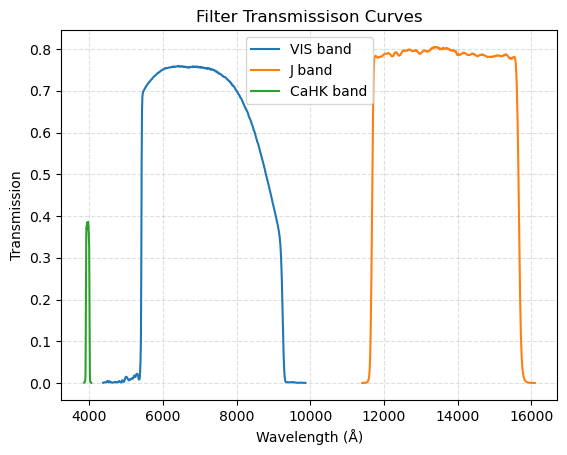

In [4]:
# Plot filters
wl_vis, tx_vis =np.loadtxt(VIS_filter, unpack=True)
wl_y, tx_y = np.loadtxt(Y_filter, unpack=True)
wl_j, tx_j = np.loadtxt(J_filter, unpack=True)
wl_h, tx_h = np.loadtxt(H_filter, unpack=True)
wl_cahk, tx_cahk =  np.loadtxt(CaHK_filter, usecols=(0, 2), unpack=True)

plt.plot(wl_vis, tx_vis, label ='VIS band')
plt.plot(wl_j, tx_j, label ='J band')
plt.plot(wl_cahk, tx_cahk, label ='CaHK band')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Transmission')
plt.title('Filter Transmissison Curves')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

In [ ]:
# Only do this once to get the values
# Run over all outer ZIPs
f_VIS = UnitFilter(wl_vis, tx_vis, name='my_g', unit='AA', dtype='photon')
f_H = UnitFilter(wl_h, tx_h, name='my_i', unit='AA', dtype='photon')
f_J = UnitFilter(wl_j, tx_j, name='my_r', unit='AA', dtype='photon')
f_Y = UnitFilter(wl_y, tx_y, name='my_r', unit='AA', dtype='photon')
f_cahk = UnitFilter(wl_cahk, tx_cahk, name='my_CaHK', unit='AA', dtype='photon')

# Zero points
zeropoint_VIS = 2.15734e-9	
zeropoint_H = 3.49475e-10	
zeropoint_J = 5.86749e-10	
zeropoint_Y = 9.35783e-10	
zeropoint_Ca = 6.96645e-9 

lib = pyphot.get_library()

nb_spectra = 0
skipped = 0
teff_list, logg_list, feh_list, alpha_list = [], [], [], [] #stellar parameters

CaHK_list, VIS_list, H_list, J_list, Y_list = [], [], [], [], []

    
for outer_zip in root_dir.glob('*.zip'):
    print(f"Processing outer ZIP: {outer_zip.name}")
    
    with zipfile.ZipFile(outer_zip, 'r') as outer:
        for inner_name in outer.namelist():
            if not inner_name.endswith('.zip'):
                continue
            
            with outer.open(inner_name) as inner_zip_bytes:
                with zipfile.ZipFile(inner_zip_bytes) as inner:
                    for fits_name in inner.namelist():
                        fits_name = fits_name.strip()
                        if not fits_name.endswith('.FITS'):
                            continue
                        
                        with inner.open(fits_name) as f:
                            # Get spectrum and wavelength
                            hdul = fits.open(f)
                            table = hdul[1].data  
                            wavelength = table['wavelength']
                            flux = table['flux']

                            # Calculate flux filters
                            flux_VIS = f_VIS.get_flux(wavelength, flux, axis=1)
                            flux_H = f_H.get_flux(wavelength, flux, axis=1)
                            flux_J = f_J.get_flux(wavelength, flux, axis=1)
                            flux_Y = f_Y.get_flux(wavelength, flux, axis=1)
                            flux_cahk = f_cahk.get_flux(wavelength, flux, axis=1)

                            mag_VIS = -2.5 * np.log10(flux_VIS.magnitude / zeropoint_VIS)
                            mag_H =  -2.5 * np.log10(flux_H.magnitude / zeropoint_H)
                            mag_J =  -2.5 * np.log10(flux_J.magnitude / zeropoint_J)
                            mag_Y =  -2.5 * np.log10(flux_Y.magnitude / zeropoint_Y)
                            mag_cahk =  -2.5 * np.log10(flux_cahk.magnitude / zeropoint_Ca)

                            #add to list
                            VIS_list.append(mag_VIS)
                            H_list.append(mag_H)
                            J_list.append(mag_J)
                            Y_list.append(mag_J)
                            CaHK_list.append(mag_cahk)

                            hdul.close()
                        match = pattern.search(fits_name)
                        if match:
                            nb_spectra += 1
                            # Get temperature, log g, methallicity and alpha from the name of the file
                            teff_list.append(float(match.group(1)))
                            logg_list.append(float(match.group(2)))
                            feh_list.append(float(match.group(3)))
                            alpha_list.append(float(match.group(4)))
                        else:
                            print("Skipped FITS with unexpected name:", fits_name)
                            skipped += 1


print("Spectra with extracted stellar parameters:", nb_spectra)
print("Number of skipped spectra:",skipped)

Processing outer ZIP: AMBRE_-5.0.zip


/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_37323/2365351080.py:55: RuntimeWarning: divide by zero encountered in log10
  mag_H =  -2.5 * np.log10(flux_H.magnitude / zeropoint_H)


KeyboardInterrupt: 

In [ ]:
# save lists to avoid recalculating
#data = {
    # Stellar parameters
    'feh': feh_list,
    'logg' : logg_list,
    'teff': teff_list,
    'alpha': alpha_list,
    
    # Euclid mag
    'VIS': VIS_list,
    'H': H_list,
    'J': J_list,
    'Y': Y_list,
    'CaHK': CaHK_list
}
# Convert to DataFrame
df = pd.DataFrame(data)

# Save to a Parquet file 
#output_file = 'Euclid_magnitude.parquet'
#df.to_parquet(output_file)
print(f"Data saved successfully to {output_file}")

Data saved successfully to Euclid_magnitude.parquet


In [5]:
# load saved data
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/Euclid_magnitude.parquet')
feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

VIS_list = df['VIS'].tolist()
H_list = df['H'].tolist()
J_list = df['J'].tolist()
Y_list = df['Y'].tolist()
CaHK_list = df['CaHK'].tolist()
    


In [6]:
# Prepare data, convert to numpy array
feh = np.array(feh_list)
logg = np.array(logg_list)
teff = np.array(teff_list)
alpha_met = np.array(alpha_list)
VIS = np.array(VIS_list)
H = np.array(H_list)
J = np.array(J_list)
Y = np.array(Y_list)
CaHK = np.array(CaHK_list)



/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_37999/1091793201.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


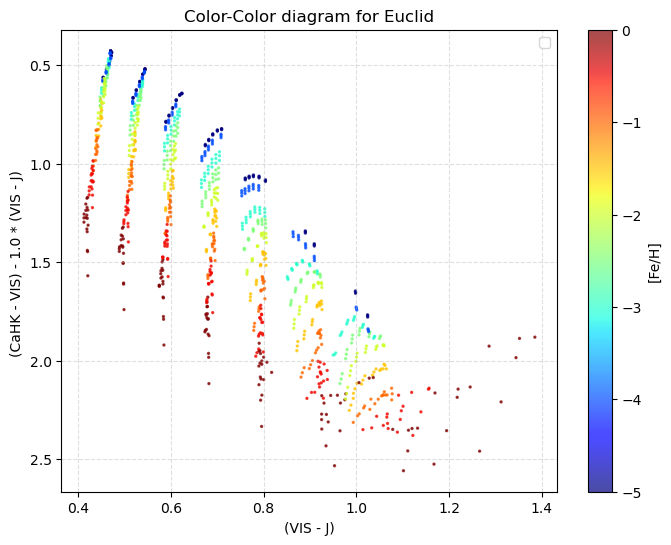

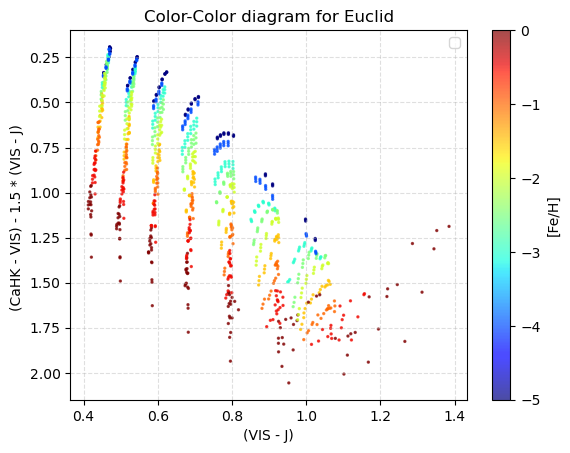

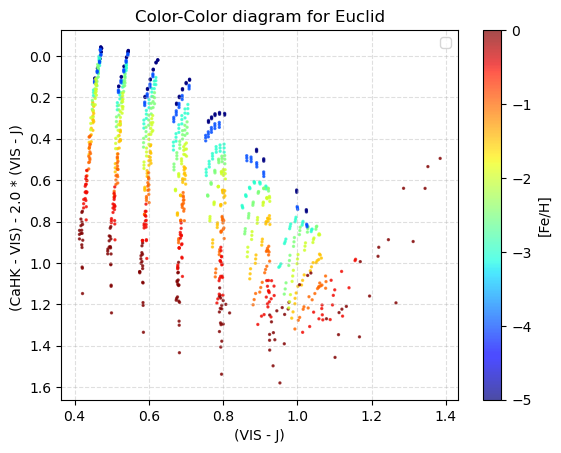

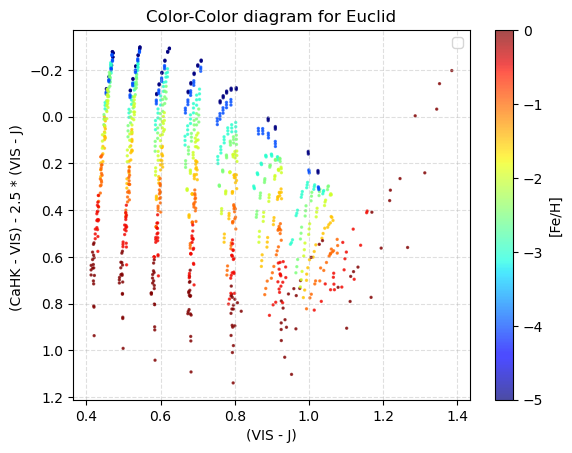

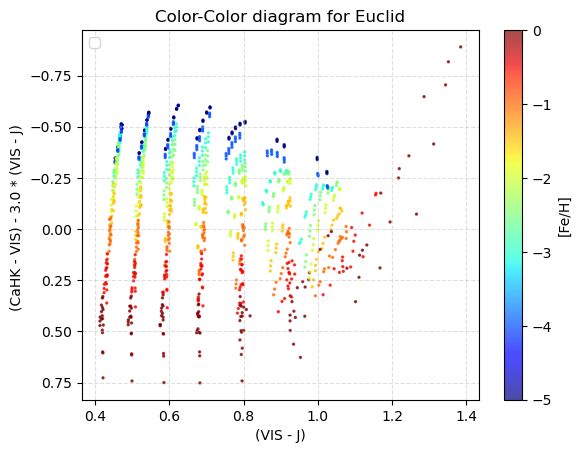

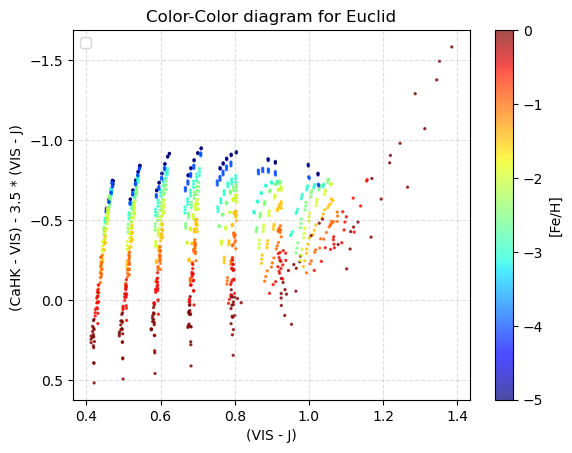

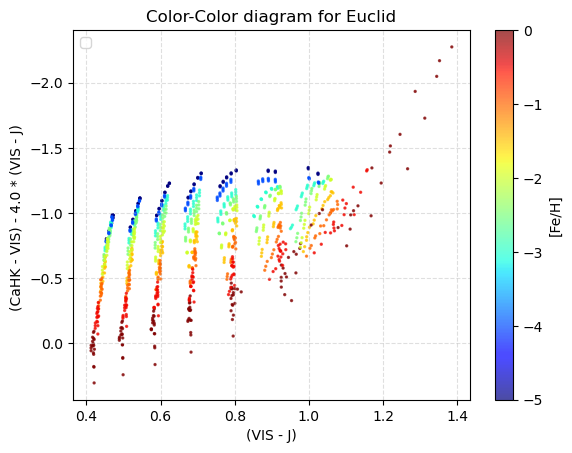

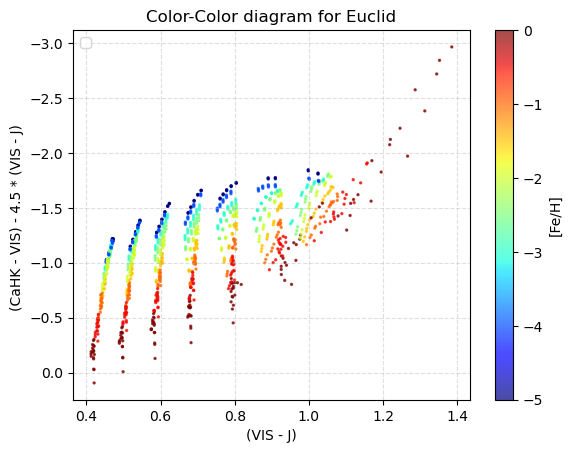

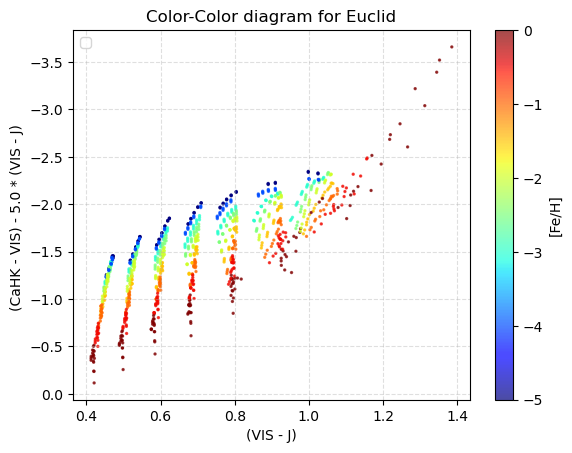

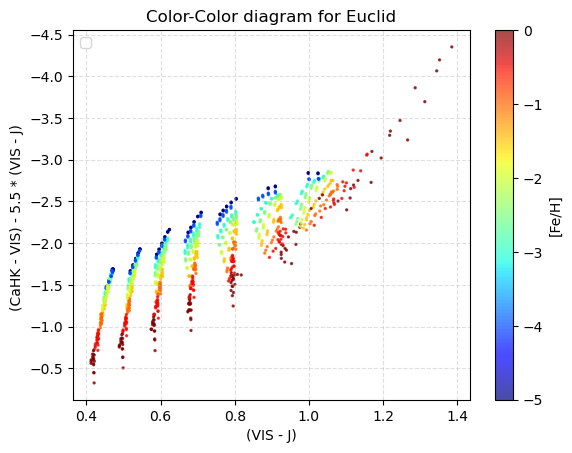

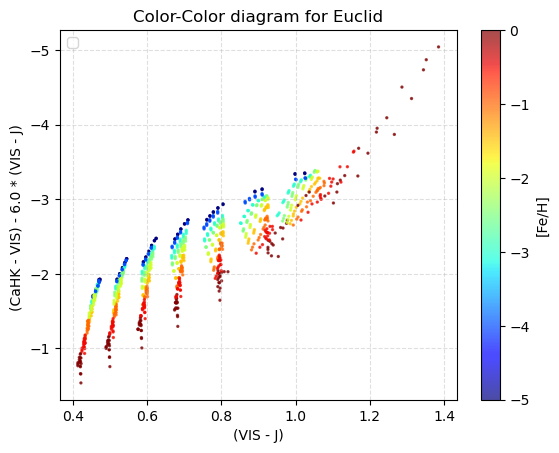

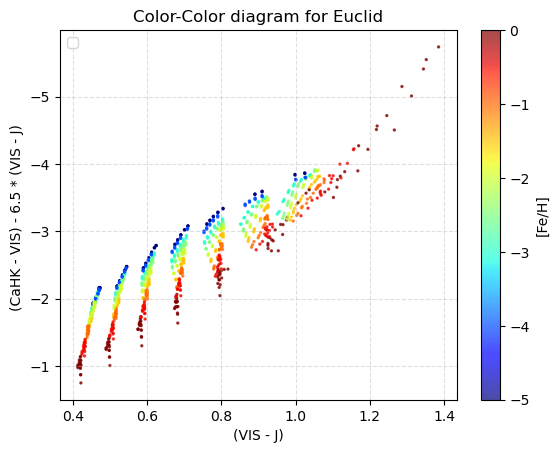

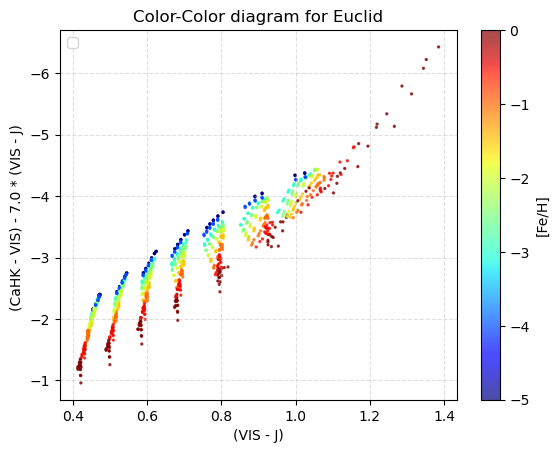

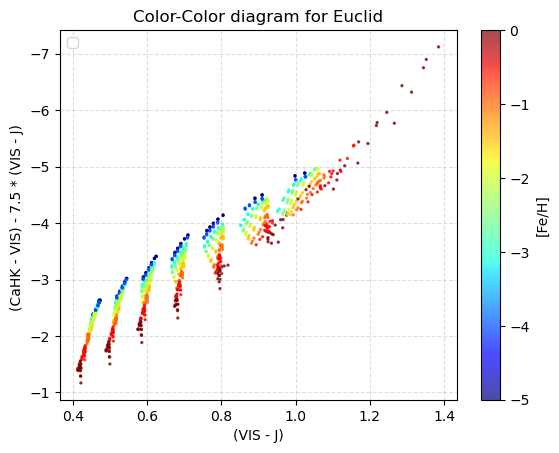

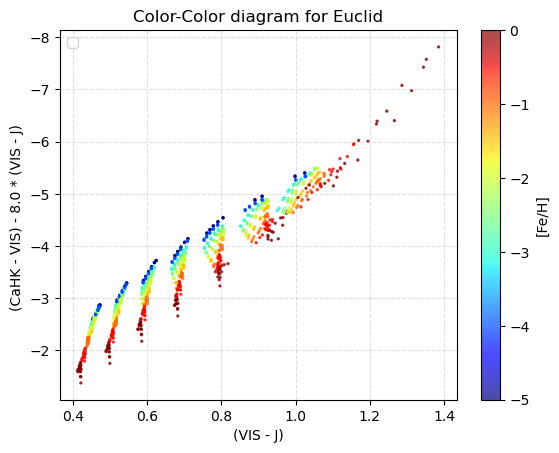

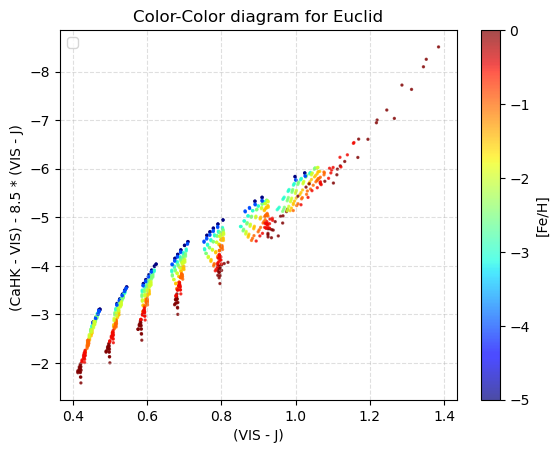

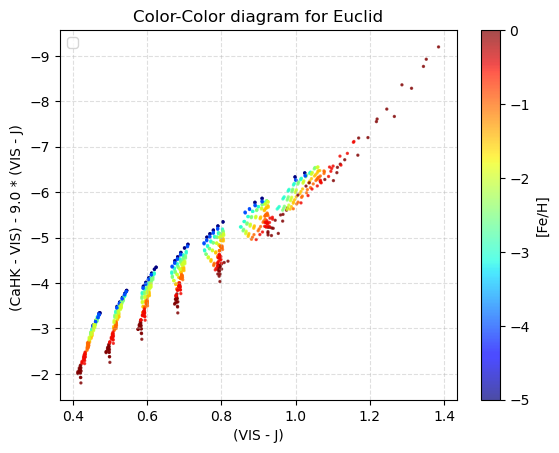

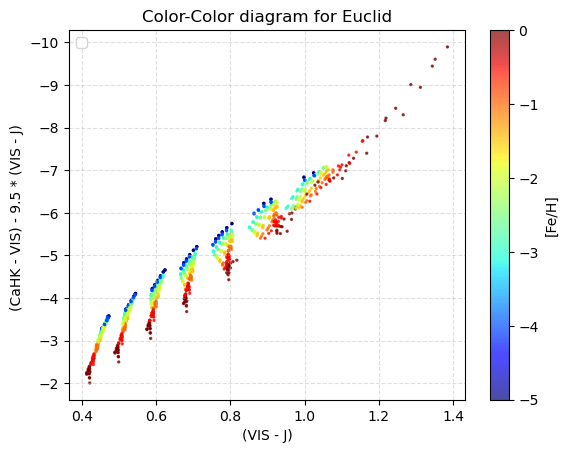

In [7]:
# Define a list of bf coefficient to try
bf_list = np.arange(1,10,0.5)

plt.figure(figsize=(8,6))

# Loop over a lot of different bf value to find the best one

for bf in bf_list:
    mask_RGB = (logg > 2) & (teff < 5700) #mask for RGB stars only
    feh_list_masked = feh[mask_RGB]


    x_axis = df.loc[mask_RGB, 'VIS'] - df.loc[mask_RGB, 'J']
    # Calculate the y value with the specific bf coefficient
    y_axis = df.loc[mask_RGB, 'CaHK'] - df.loc[mask_RGB, 'VIS'] - bf*(x_axis) 

    sc = plt.scatter(x_axis,y_axis, c=feh_list_masked, cmap='jet', s=2, alpha=0.7)
    plt.gca().invert_yaxis()
    plt.xlabel('(VIS - J)')
    plt.ylabel(f'(CaHK - VIS) - {bf} * (VIS - J) ')
    plt.title('Color-Color diagram for Euclid')
    plt.colorbar(label='[Fe/H]')
    #plt.xlim(0,1.5)
    #plt.ylim(0.1,-1.2)
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.legend()

    plt.show()

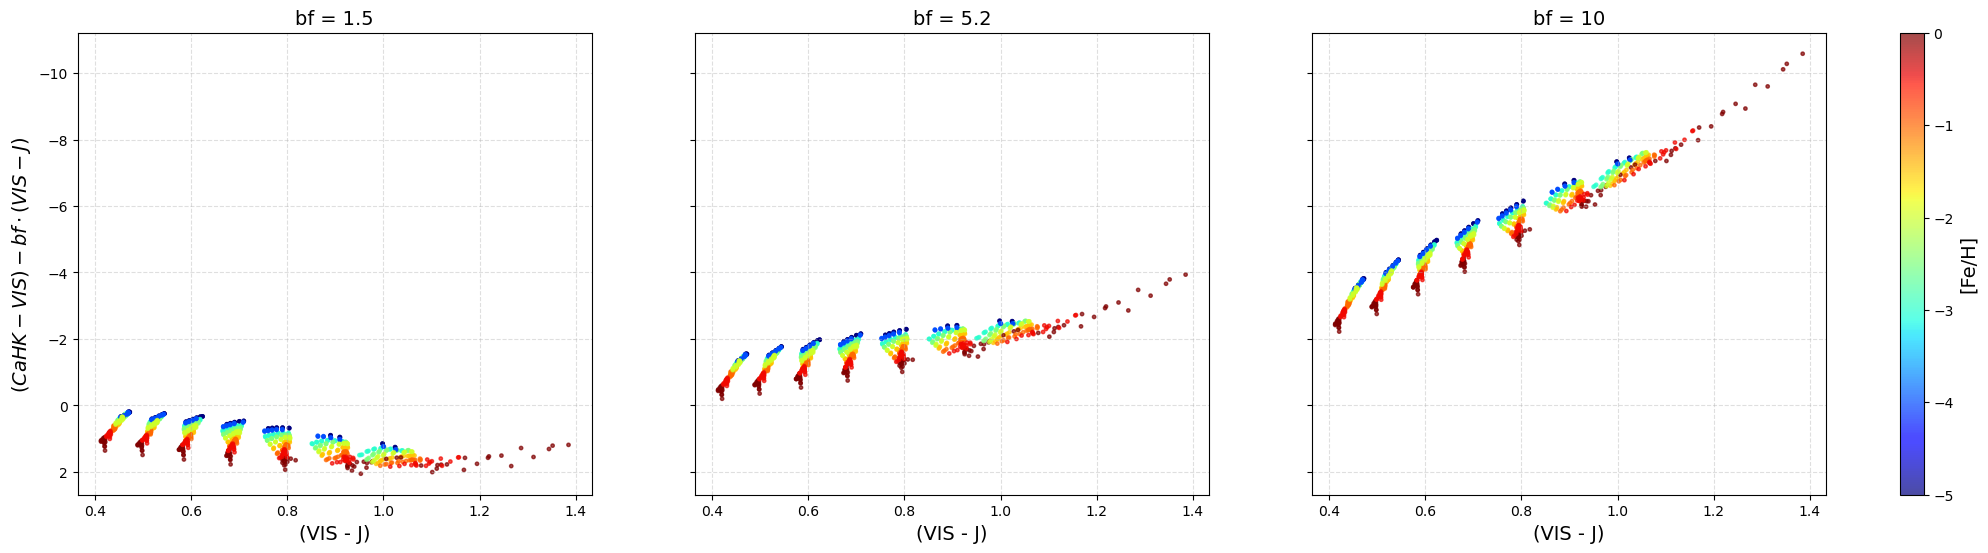

In [10]:
# Define the specific bf values to show for the report
bf_list = [1.5, 5.2, 10]

# Create a figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

# Loop over the values and the axes simultaneously
for bf, ax in zip(bf_list, axes):
    # Apply the mask
    mask_RGB = (logg > 2) & (teff < 5700)
    feh_list_masked = feh[mask_RGB]

    # Calculate axes
    x_axis = df.loc[mask_RGB, 'VIS'] - df.loc[mask_RGB, 'J']
    y_axis = df.loc[mask_RGB, 'CaHK'] - df.loc[mask_RGB, 'VIS'] - bf * (x_axis)

    # Plot on the specific subplot axis (ax) rather than plt
    sc = ax.scatter(x_axis, y_axis, c=feh_list_masked, cmap='jet', s=6, alpha=0.7)
    
    ax.invert_yaxis()
    ax.set_xlabel('(VIS - J)',fontsize='14')
    ax.set_title(f'bf = {bf}',fontsize='14')
    ax.grid(True, linestyle='--', alpha=0.4)

# Set the Y-label only on the first plot
axes[0].set_ylabel(r'$(CaHK - VIS) - bf \cdot (VIS - J)$',fontsize='14')

# Add a single colorbar for the whole figure
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label(label='[Fe/H]', fontsize=14)

plt.savefig('Euclid.svg', format='svg', bbox_inches='tight')

plt.show()

/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_37323/799275039.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


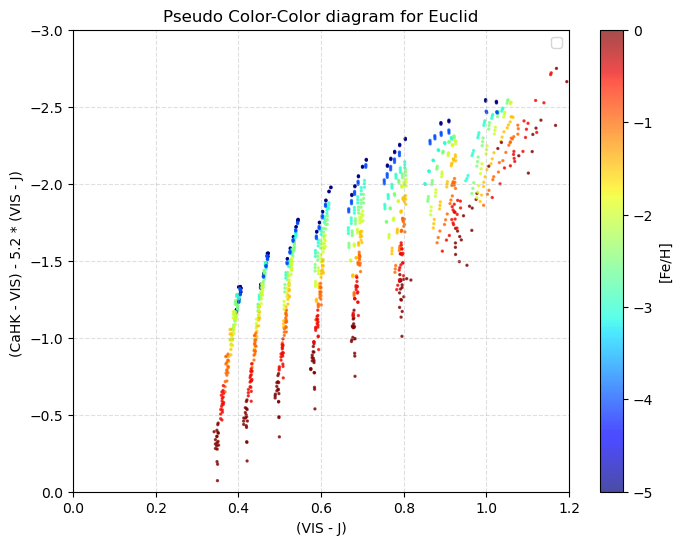

In [25]:
# Plot best value of bg
plt.figure(figsize=(8,6))
mask_RGB = (logg > 2) & (teff < 6000) #mask for RGB stars only
feh_list_masked = feh[mask_RGB]
bf = 5.2 # best value obtained from before


x_axis = df.loc[mask_RGB, 'VIS'] - df.loc[mask_RGB, 'J']
y_axis = df.loc[mask_RGB, 'CaHK'] - df.loc[mask_RGB, 'VIS'] - bf*(x_axis) 

sc = plt.scatter(x_axis,y_axis, c=feh_list_masked, cmap='jet', s=2, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel('(VIS - J)')
plt.ylabel(f'(CaHK - VIS) - {bf} * (VIS - J) ')
plt.title('Pseudo Color-Color diagram for Euclid')
plt.colorbar(label='[Fe/H]')
plt.xlim(0,1.2)
plt.ylim(0,-3)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()

plt.show()